<a href="https://colab.research.google.com/github/channel1umut-lang/Deep-Learning/blob/main/0009_LinearVsNonLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DL Datasets/08-email_classification_svm.csv')

In [ ]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [ ]:
df.describe()

,subject_formality_score,sender_relationship_score,email_type
count,1000.000000,1000.000000,1000.000000
mean,-1.009046,-0.006300,0.498000
std,0.654219,1.059501,0.500246
min,-3.532770,-2.218219,0.000000
25%,-1.252867,-1.006076,0.000000
50%,-0.994760,0.439233,0.000000
75%,-0.754839,0.994943,1.000000
max,2.180933,1.699497,1.000000


In [ ]:
# Email Classification (Work vs Personal)
# subject_formality_score -> Score based on formality of subject line
# sender_relationship_score -> Score representing how familiar the sender is
# email_type -> 0 = Personal, 1 = Work email

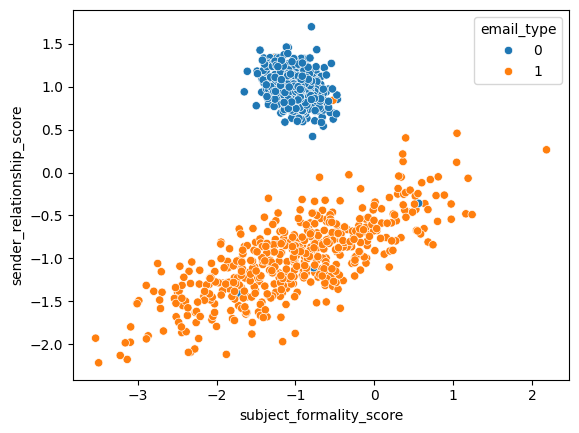

In [ ]:
sns.scatterplot(x=df['subject_formality_score'],y=df['sender_relationship_score'],hue=df['email_type'])
plt.show()

In [ ]:
# it is obvious that we can classify this kind of dataset with a linear approach

In [ ]:
X = df[["subject_formality_score", "sender_relationship_score"]].values
y = df["email_type"].values   # 0 or 1

In [ ]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]])

In [ ]:
y

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)   # shape: (800, 2)
X_test  = torch.tensor(X_test,  dtype=torch.float32)   # shape: (200, 2)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # shape: (800, 1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)  # shape: (200, 1)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [ ]:
X_train.ndim

2

In [ ]:
y_train.ndim

2

In [ ]:
from torch import nn

In [ ]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. let's create two layers these time with 5 neurons
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), outputs 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, outputs 1 feature (y)

    def forward(self, x):
        # we can define this layers in a sequential order and then we do not need to do the step below, but we need to learn this as well
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

In [ ]:
model_0 = ClassificationModel() # Created instance

In [ ]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in in the loss function

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [ ]:
# Calculate accuracy. we can use torchmetrics for measuring accuracy, but let's do it manually now
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item() # torch.eq() calculates when two tensors are equal
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [ ]:
#for instance
#torch.eq(torch.tensor([1,1,1]), torch.tensor([0,1,0])).sum().item() #shows how many equal value exist among those two tensors.

In [ ]:
# let's look at the predictions without training to understand logits and sigmoid

In [ ]:
# View the frist 5 predictions
y_logits = model_0(X_test)[:5]

In [ ]:
y_logits

tensor([[-0.1342],
        [-0.2908],
        [-0.1631],
        [-0.2298],
        [-0.1364]], grad_fn=<SliceBackward0>)

In [ ]:
# so how do we decide if they are 0 or 1? personal or work related? we need sigmoid to make sense of them

In [ ]:
y_pred_probs = torch.sigmoid(y_logits)

In [ ]:
y_pred_probs

tensor([[0.4665],
        [0.4278],
        [0.4593],
        [0.4428],
        [0.4660]], grad_fn=<SigmoidBackward0>)

In [ ]:
y_preds = torch.round(y_pred_probs) # if they are above 0.5 then we can call it 1 and if they are less 0

In [ ]:
y_preds

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

In [ ]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [ ]:
calculate_accuracy(y_test[:5], y_preds) # As we can see just 1 matches exist and it corresponds 20%

60.0

In [ ]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    # Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits)) #Bu kismi accurracy icin yazdi... torch.sigmoid(y_logits) → Logitleri [0,1] aralığında olasılık değerlerine dönüştürürtorch.round() → Olasılığı 0.5 eşik değerine göre yuvarlar (≥0.5 ise 1, <0.5 ise 0)

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits. Yani sigmoidli BCE kullandik. Direkt ham logit alır (sigmoid uygulanmamış). İçeride otomatik olarak sigmoid + binary cross entropy yapar
                   y_train) # y_logits: Modelin ham çıktıları. y_train: Gerçek etiketler (0/1)
    acc = calculate_accuracy(y_test=y_train, # y_test=y_train-> gercekler. y_pred=y_pred-> Tahminler
                      y_pred=y_pred)

    # 3. optimizer reset
    optimizer.zero_grad()

    # 4. back prop and optimization
    loss.backward()

    # 5.
    optimizer.step()

    ### Testing
    model_0.eval() #Modeli değerlendirme moduna al (dropout/devre dışı)
    with torch.inference_mode(): #Gradient hesaplamayı kapat (hız ve bellek tasarrufu)
        # 1. Forward pass
        test_logits = model_0(X_test) #Test verileriyle tahmin yap (ham logit olarak)
        test_pred = torch.round(torch.sigmoid(test_logits)) # Logitleri 0/1 sınıf etiketlerine çevir
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,#Test verilerinin kayıp değerini hesapla
                            y_test)
        test_acc = calculate_accuracy(y_test=y_test, #Test verilerinin doğruluk oranını hesapla
                               y_pred=test_pred)

    if epoch % 5 == 0: # Her 5 epoch'ta bir ekrana yazdır
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%") #Eğitim ve test sonuçlarını karşılaştırmalı göster

Epoch: 0 | Loss: 0.72349, Accuracy: 49.75% | Test loss: 0.71765, Test acc: 52.00%
Epoch: 5 | Loss: 0.70700, Accuracy: 49.75% | Test loss: 0.70068, Test acc: 52.00%
Epoch: 10 | Loss: 0.69118, Accuracy: 49.75% | Test loss: 0.68440, Test acc: 52.00%
Epoch: 15 | Loss: 0.67597, Accuracy: 49.75% | Test loss: 0.66874, Test acc: 52.00%
Epoch: 20 | Loss: 0.66130, Accuracy: 49.75% | Test loss: 0.65364, Test acc: 52.00%
Epoch: 25 | Loss: 0.64712, Accuracy: 49.75% | Test loss: 0.63904, Test acc: 52.00%
Epoch: 30 | Loss: 0.63337, Accuracy: 50.12% | Test loss: 0.62490, Test acc: 52.00%
Epoch: 35 | Loss: 0.62002, Accuracy: 52.62% | Test loss: 0.61117, Test acc: 54.00%
Epoch: 40 | Loss: 0.60702, Accuracy: 58.63% | Test loss: 0.59780, Test acc: 63.50%
Epoch: 45 | Loss: 0.59435, Accuracy: 64.50% | Test loss: 0.58478, Test acc: 70.50%
Epoch: 50 | Loss: 0.58198, Accuracy: 70.62% | Test loss: 0.57207, Test acc: 76.50%
Epoch: 55 | Loss: 0.56988, Accuracy: 76.75% | Test loss: 0.55965, Test acc: 81.50%
Epoch: